## Introduction

## 0.1 - Imports
The code block below represents where all imports for the noteboook are initilised. 

In [243]:
# Import Library
import pandas as pd
import numpy as np

# Sklearn Imports:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# Data Display Imports
import matplotlib.pyplot as plt

## 0.2 Import Datasets
This code block represents where all the datasets that will be worked on throughout this notebook are imported and initilised. 'customer_features' is copied in order to preserve the original data, whilst ammendments and changes are implemented. 

In [211]:
# Import the scaled dataset
customer_features_scaled = pd.read_csv('../0_Data/processed_data/customer_features_scaled.csv')
customer_features = pd.read_csv('../0_Data/processed_data/customer_features.csv')

# Create a copy of the dataset we will be working on: 
scaled_df = customer_features_scaled.copy()

## 1.0 Pre-pipeline Steps
At this point scaling and preprocessing has been completely finished. However there are still a few steps we need to confirm before initlising the pipeline. The first is removing customer_id from the dataset but keeping to hand for later. This is done because customer_id does not provide any benifit for the models in terms of unveiling consumer behaviour and secondly, it is the only column that did not have StandardScalar applied to it - as we did not want to change the actual customer_id's.

In [212]:
# pull customer_id into its own dataset; 
customer_ids = scaled_df['customer_id']

# Drop customer_id from the working dataset: 
scaled_df = scaled_df.drop(columns=['customer_id'])

# Implement a function that checks if customer_id was successfully removed.
def customer_features_removal(df):
    if scaled_df.columns.all() == 'customer_id':
        print("'customer_id' still present")
    else: print("'customer_id' successfully removed")

# Call the customer_features_removal function using scaled_df. 
customer_features_removal(scaled_df)

'customer_id' successfully removed


## 2.0 - Machine Learning Pipeline Implementation

### 2.1 - KMeans Algorithm
Before implementing k-means algorithms, we need to identify what value of 'k' is most suitable for our model. This will be done using elbow and silhoutte approaches. 

**'k' Value indentification methodology:**
The elbow method used 'inertia' as a way of measuring how closely points are plotted to each other. The logic is, as you add more points (increasing k) inertia decreased where eventually it hits 0. The key with this test is not identifying the lowest point but where the elbow is situated (displayed visually within a graph). The elbow represents the point at which increasing values of k stops providing value and start diluting clusters. Using the elbow method should result in a plot that decreases sharply at first and then levels off. It is at this point of the leveling off (the elbow) where the value of 'k' is the best choice for the data. 

Sometimes, the result of the elbow method does not produce a clear and distinct point of leveling off. This is why it is useful to deploy a second method of identifying the most suitable value of 'k' - using silhouete score. Silhouette score is reponsible for measuring the quulity of the clusters that are created. The silhouette score measures two things. The first is the how close each point is to the other points within its own cluster as well as how far away it is from points in the next closest cluster. The idea is, if a point sits close to other points within its own cluster and far away from other clusters, it is given a high score. However, in the opposite case, if a point is sitting closer to another cluster, the score is lower. Scores are issued in the range of -1 to 1. By combining the average silhouette score for each point the result should indicate how well defined each cluster is - value of k with the highest silhouette score is usually the a solid indicator of the best value of 'k'. 

### 2.2 - Determining K
KMeans is a clustering algorithim that is distance based. The idea behind its implementation within this context is to uncover clusters within the data. This is powerful as patterns that arent necessirily present then looking at raw data is uncovered during visual segments.

Before implementing the algorithm, the value of k needs to be determined. In this context K represents how many different groups or segments the algorithm will produce. It is important to get 'k' for multiple reasons: 

- **K to low**: If the value of k is too low, unique and distinct bevahours are often missed where different groups are missed together - removing the point of the algorithm entirely. For example, if k = 2 then our entire dataset would be split into two segements and with the range of features we have in the dataset, two segements is not enough to uncover any meaningful behaviours

- **k to high**: On the other hand if k is too high clusters fracture into indisgusiable segemnts that do not represent groupings of behaviour. 

- **Getting k correct**: Getting k correct represents the point where clusters represent meaningful and insightful behvioural patterns, which can be usd to uncover patterns within the data that would otherwise been missed. This is why finding the best value of 'k' is important. Below the first steps of identifying 'k' will be made. Starting off with Sihouette score and the elbow method. 

In order to find out what the value of 'k' is to ensure the KMeans algorithm is impplemented efficiently a two-step visulisation will be used. This is done using the elbow method to reveal what value of 'k' ensures KMeans works best and a second method that reinforces whether this value of 'k' is sound in principle - silhouette score. 

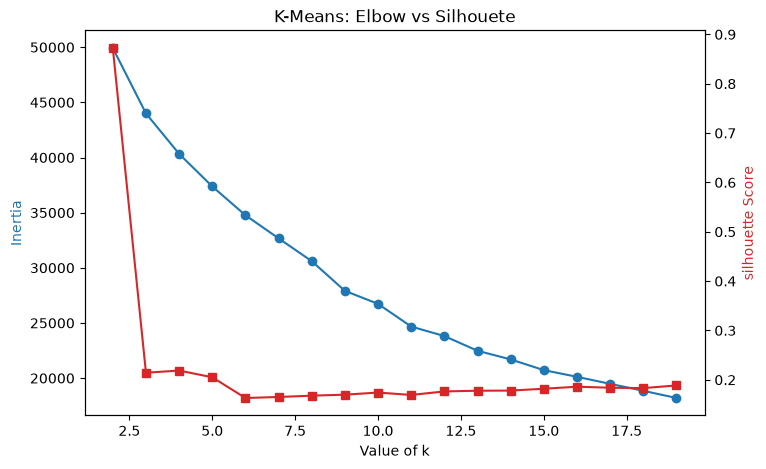

In [213]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 10 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    # random_state is a fixed value to ensure reproduceable results. 
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(scaled_df)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(scaled_df, labels))

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

**Results**
As stipulated before we are looking for 2 particular behaviours. Firstly, with inertia (blue line) the visulisation we are looking for is the 'elbow' or the point at which a steep decline levels of.  The second, silhouette score is expected to peak at some point on the line indicating cleanly seperated points. In this case, both of these behaviours are not present - Inertia has no elbow and silhouette score has no defining peak. This is an indication that there is a segment of points within the data that is interfeering with both of these measurements. A low sihouette score, can be attributed to mutiple points that are pulled apart from others. In this case, a likely cause of this is the wholesale transactions that were left in during preprocessing. IN order to confirm this further investigation; specifically on  is needed.  

To start building a picture of what is effecting the results, a describe() filtering to display only min and max values will be displayed below. This aims to provide an insight into range between the smallest and largest values in each feature - if the range is large, that StandardScalar scaled alongside out outliers and their values are now causeing issues. 

In [214]:
scaled_df.describe().loc[['min', 'max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-2.036680,-48.946912,-0.410267,-0.326596,-0.676258,-0.690148,-2.483556,-1.369769,-1.426411,-0.647945
max,41.527424,22.346992,31.460162,42.868300,4.668382,21.270907,3.292813,1.853239,10.654583,1.543341


**Min & Max Descibe Evaluation**
As previously mentioned, StandardScalar has been deployed on te data within the preprocessing steps. When implemented on data that contains no outliers, StandardScalar produces values that all sit within a fairly tight radius. Displaying the minimum and maximum values above shows that there are cases where values do not sit within a tight range. For example in 'total_spend' we see that there is at least one case where a customer is -2 standard devisations from the average opposed to the maximum of +40 standard deviations. This is evidence that the extreme outliers are distorting clusters.  

This issues presents a choice. Wholesale transactions can be removed completely or moved to their own dataset. As mentioned in the preprocessing steps, there are multiple instances of wholesale transactions happening repeatidly, representing a genuiene business sgement. Rather than removing this data completely, it is important to retain it and work on these transactions within their own dataset. The first step in doing this is to identify a point in which transactions stop being classed as retail customers and are moved to wholesale transactions status. 

Rather than drawing a specific value (like a certin total_spend or quantity amount) it is better to visually inspect the spread of transactional values - strting with 'total_spend' 

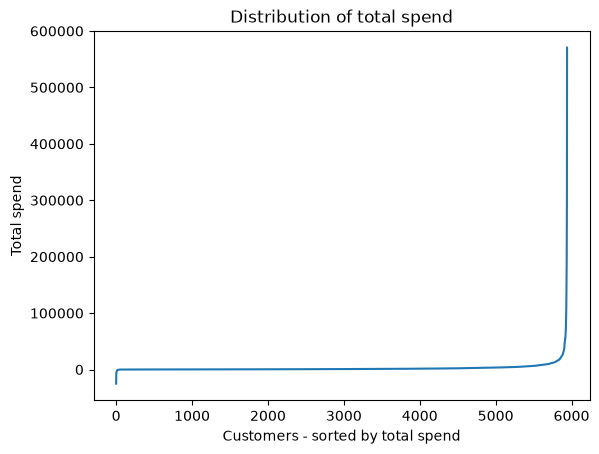

In [215]:
# Create a variable using the unscaled customer_features - grouped on 'customer_id' and 'total_spend':
transaction_spend_split = customer_features.groupby('customer_id')['total_spend'].sum().sort_values()

# Initilise a plot to display the results:
# Set figure size:
plt.Figure(figsize = (8, 5))
# Plot the values stored in the variable initilised above:
plt.plot(transaction_spend_split.values)
# X-label: Where each customer sits on an ordered total_spend list:
plt.xlabel('Customers - sorted by total spend')
# Y-label: Total Spend amount:
plt.ylabel('Total spend')
# PLot title:
plt.title('Distribution of total spend')
# Display the plot:
plt.show()

**Plot Evaluation**
The plot above confirms the above claims, that there is a very small number of observations with extreme values - specifically total_spend. Now the curve has been identified, we can move our investigation closer to the curve which occurs somewhere between the 5000th and 6000th customer. The next step is to produce another plot, this time focusing on only the customers between the 5500 and 6000 range:

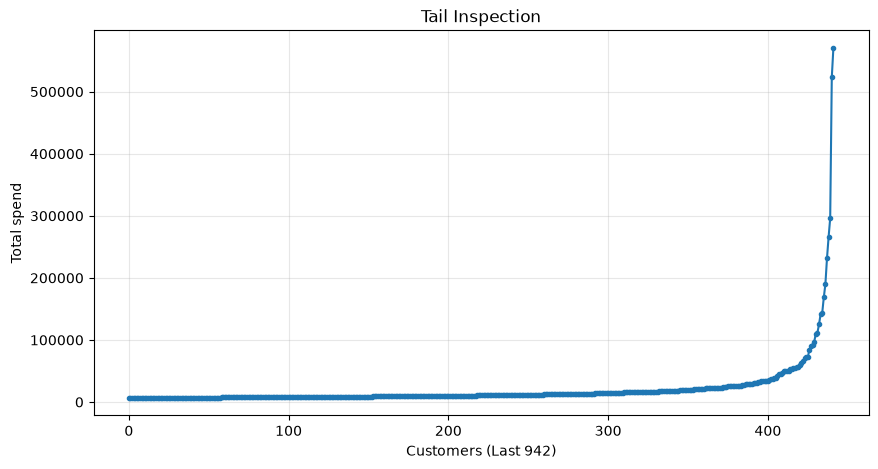

In [216]:
# Initilise another variable focusing on the top 442 Customers:
tail_inspection = transaction_spend_split[5500 : 5942].reset_index(drop = True)

# Set figure size:
plt.figure(figsize = (10, 5))
#
plt.plot(tail_inspection.index, tail_inspection.values, marker = 'o', markersize = 3)
#
plt.xlabel('Customers (Last 942)')
#
plt.ylabel('Total spend')
# Set plot title
plt.title('Tail Inspection')
#
plt.grid(True, alpha = 0.3)
# Display the plot
plt.show()

**Plot Analysis**
Looking at the last ~500 customers we can see that it is around the last 42 customers (~ the 400 mark) where transactions change exponentially. While this information draws a clearer picture, it still does not provide enough information to establish a definative split between retail and wholesale consumers. 

Using total_spend alone is useful in identifying the general behaviour of values, but it does not provide a complete picture. In order to draw a sensible conclusion a final step integrating 'total_item_count' should be used. The idea behind this final check is to catch any valuable customers that by high-costing products. In this case 'total_spend_' alone runs the risk of categorising a loyal repeat customer in with wholesale transactions. Furthermore, it is very rare that wholesale transacitons will have low spend and quantity amounts, as such is the nature of wholesale transacitions.

It is clear that relying on visual inspection is not sufficient in identifying where the divide between the two different types of consumers lies. To solve this a different approach will be used. 

In [217]:
# Initilise a variable representing the 95th percentile value for spend and qty
# Total Spend
spend_cutoff = customer_features['total_spend'].quantile(0.95)
# Total Item Count
quantity_cutoff = customer_features['total_item_count'].quantile(0.95)

# Establish a boolean mask marking a customer as True for 95th percentile values. 
wholesale_marker = ((customer_features['total_spend'] >= spend_cutoff) & 
                    (customer_features['total_item_count'] >= quantity_cutoff))

# Remove all instances of customers who are above the threshold: 
# Store the observations 
retail_features = customer_features[~wholesale_marker]

# Print values: 
print(f"Spend Cutoff Value: £{spend_cutoff:.2f}")
print(f"Quantity Cutoff Value: £{quantity_cutoff:.2f}")
print(f"Remaining Retail Cusotmers: {len(retail_features)}")


Spend Cutoff Value: £8746.50
Quantity Cutoff Value: £5180.85
Remaining Retail Cusotmers: 5708


In [218]:
# Re-initilise Feature_cols variable, without customer_id: 
feature_cols = ['total_spend', 'atv', 'total_visits', 'total_item_count',
                'cancellation_rate', 'unique_products', 'time_of_day', 'day_of_week',
                'discount_rate', 'loyalty_member']

# Initilise StandardScaler:
scaler = StandardScaler()

# Re-run StandardScalar on the retail dataset: 
retail_scaled = scaler.fit_transform(retail_features[feature_cols])

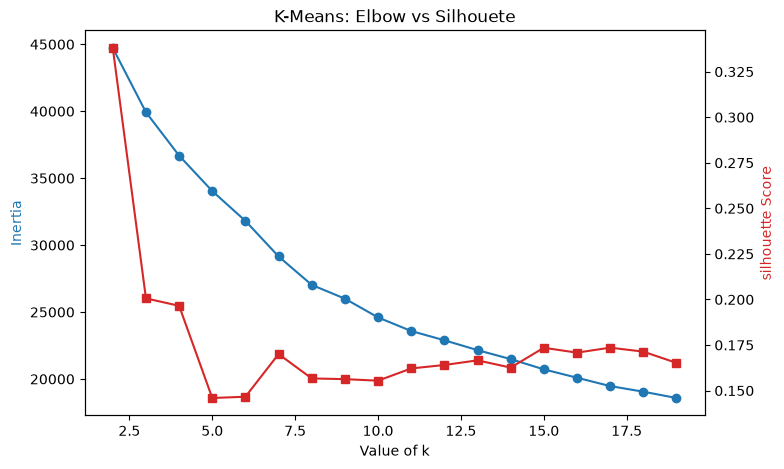

,k,inertia,silhouette
0,2,44723.208260,0.337985
1,3,39925.921678,0.200610
2,4,36684.290386,0.196526
3,5,34038.815967,0.145943
4,6,31808.353917,0.146631
5,7,29154.276817,0.170045
6,8,27027.837373,0.156680
7,9,26001.141865,0.156290
8,10,24598.489368,0.155442
9,11,23583.308883,0.162159


In [219]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 10 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    # random_state is a fixed value to ensure reproduceable results. 
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(retail_scaled)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(retail_scaled, labels))

# Implement a dataframe showing results as numerical values:
results_df = pd.DataFrame({
    'k' : list(k_range),
    'inertia' : inertias,
    'silhouette' : silhouette_scores
}
)

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

results_df

after removing the wholesale customers, the split is better, however the peak being at 2 is still present which sugesstes there is still an extreme value that is effecting the data. This will be investigated using a min and max describe - this cofirms the difference from the wholesale removal and give indication that there might be something effecting the data. 

In [220]:
pd.DataFrame(retail_scaled, columns=feature_cols).describe().loc[['min','max']]

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
min,-13.394317,-56.511128,-0.691893,-1.641791,-0.657119,-0.824025,-2.479732,-1.369313,-1.398501,-0.646090
max,7.422657,10.269374,13.995024,12.561533,4.630330,9.651345,3.270637,1.838803,10.456100,1.547772


the results are much better than previous and therefore confirm the wholesale customers have been revmoed. although some features still indicate that outliing values still remain. Specifically on ATV with the minimum being negative 56 standard deviations below average as well as a low total_spend that sits outside the average standard deviation range. 

this indicates that the wholesale removal was suitable for removing high end extremes, but there is still some issues/ inconsitencies with extreme values. 

printing 

In [221]:
customer_features.nsmallest(5, 'total_spend')[['customer_id', 'total_spend', 'atv', 'total_visits', 'total_item_count']]

,customer_id,total_spend,atv,total_visits,total_item_count
5053,17399,-25111.09,-25111.090000,1,-1
572,12918,-10953.50,-3651.166667,3,-1
3503,15849,-5876.34,-5876.340000,1,-1
3414,15760,-5795.87,-1159.174000,5,-1
4635,16981,-4620.86,-4620.860000,1,-1


There is clearly outliers here, but these would not have been caught in the originl outlier removal round due to being negative values. The consistency between them is that each share a value of total_item_count = < 0. 

In [ ]:
# Sum the number of instances where total_item_count is less than 0:
(customer_features['total_item_count'] <= 0).sum()

np.int64(99)

with only 99 observations of total_item_count being less than 0 (or about 1.7%) this is small enough to remove all instances comeplelty and re-test the elbow and silhoutte tests. 

In [223]:
# Remove all instances of total_item_count being less than 0
retail_features = retail_features[retail_features['total_item_count'] > 0]

# Re-fit Standard Scalar: 
retail_scaled = scaler.fit_transform(retail_features[feature_cols])

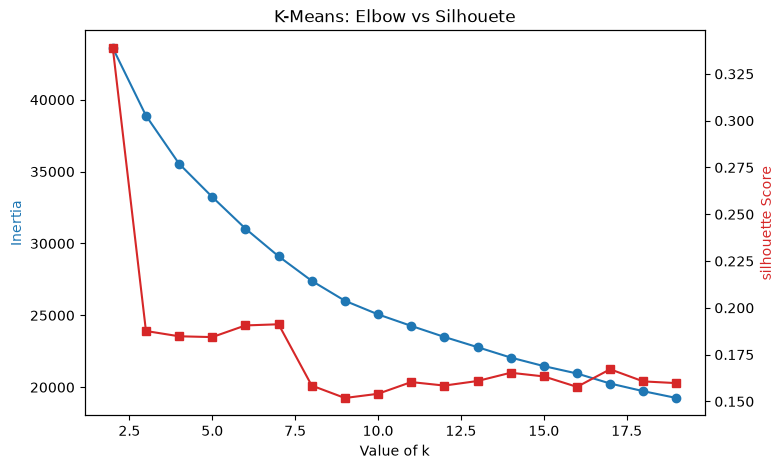

,k,inertia,silhouette
0,2,43600.438842,0.338837
1,3,38896.420388,0.187630
2,4,35546.451112,0.184802
3,5,33235.601987,0.184372
4,6,31036.404605,0.190600
5,7,29108.451675,0.191219
6,8,27401.245965,0.158476
7,9,26015.405522,0.151830
8,10,25067.607448,0.154075
9,11,24267.206854,0.160339


In [224]:
# Initlise inertias and silhouette scroes lists as the metjod of storing results. 
inertias = []
silhouette_scores = []

# Initilise a range for k to be tested (2 through 10 inclusive)
k_range = range(2, 20)

# Initilise for each loop:
for k in k_range:
    # For each value of k re-initilise a KMeans algrithm wit the same parameters
    # random_state is a fixed value to ensure reproduceable results. 
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(retail_scaled)
    # Add the result km to inetias list.
    inertias.append(km.inertia_)
    # Use a seperate function using the original data and the labels data calculated above. 
    # This measures the degree of seperation between clusters - the result is appeneded to silhouete_scores list. 
    silhouette_scores.append(silhouette_score(retail_scaled, labels))

# Implement a dataframe showing results as numerical values:
results_df = pd.DataFrame({
    'k' : list(k_range),
    'inertia' : inertias,
    'silhouette' : silhouette_scores
}
)

# Initilise a plot to display the results from the inertias and silhouette_score lists. 
# Inetias Plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Display the line with circles connected by a line: 
ax1.plot(k_range, inertias, 'o-', color = 'tab:blue', label = 'Inertia')
ax1.set_xlabel('Value of k')
ax1.set_ylabel('Inertia', color = 'tab:blue')

# Silhouete_score Plot:
ax2 = ax1.twinx()
# Display the line with squares connected by a line:
ax2.plot(k_range, silhouette_scores, 's-', color = 'tab:red', label = 'Silhouette')
ax2.set_ylabel('silhouette Score', color = 'tab:red')

# Title the plot:
plt.title('K-Means: Elbow vs Silhouete')

# Display the visulisation:
plt.show()

results_df

at this point k=2 is continously being a dominant value across two different rounds of outlier removal. It might be a suitable choice for the value of K. To confirm this a new strategy will be used. Instead of trying to diagnose if there is errors within the data, the reason for the split is what will be searched for. 



In [225]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = km2.fit_predict(retail_scaled)

retail_features['cluster'] = labels2
retail_features.groupby('cluster')[feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
cluster,,,,,,,,,,
0,822.633877,255.075132,3.609856,485.409081,0.097953,47.479664,12.592425,2.564235,0.117639,0.288358
1,4953.323155,395.061605,16.535343,2937.314969,0.178758,195.692308,12.537422,2.610187,0.118063,0.321206


using k=2 seems to have produced a split comparable to low engagement and high engagement, since cluster one has a consistent larger gap from group 0 (IE total spend, atv, total_visists). 
running k-means at 7 as well: 

In [ ]:
km7 = KMeans(n_clusters=7, random_state=42, n_init=10)
labels2 = km7.fit_predict(retail_scaled)

retail_features['cluster'] = labels2
retail_features.groupby('cluster')[feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week,discount_rate,loyalty_member
cluster,,,,,,,,,,
0,3262.779901,317.950860,11.693456,1959.339839,0.155368,156.594719,12.518944,2.832377,0.118148,0.250287
1,610.088406,243.966556,2.660603,362.404500,0.009726,39.710866,12.680230,2.619435,0.098856,0.000000
2,323.481187,196.026409,1.812785,170.392694,0.012545,11.767123,12.360731,2.337900,0.344463,0.191781
3,7140.827938,347.119684,24.395062,4255.537037,0.186014,261.058642,12.487654,2.469136,0.119850,0.327160
4,827.194655,266.084414,3.387534,487.216802,0.051746,48.321590,12.767841,2.592593,0.110695,1.000000
5,3146.036280,1485.126692,2.224299,1643.345794,0.037461,69.644860,12.476636,2.242991,0.112209,0.364486
6,935.784228,190.517381,5.213004,545.345291,0.389243,46.457399,12.290359,2.316143,0.114366,0.153587


using 7 clusters produced more granular segements.
EXPAND

both k = 2 and k = 7 produce intesting and meaningful segments but with k = 7 providing richer results. and interesting aspect to investigate is the within cluster 4 and its value of 1.000 in loyalty member. similar to discount_rate, are these features influencing the others. The next code block will remove loyalty_member and dicount_rate and evaluate if there is a difference in results. 

In [232]:
# Remove the two features from the dataset: 
binary_removal_features = retail_features.drop(columns=['loyalty_member', 'discount_rate'])

# Create a new list: 
removed_feature_cols = [col for col in feature_cols if col not in ['loyalty_member', 'discount_rate']]

# Refit Standard Scalar: 
binary_removed_scaled = scaler.fit_transform(binary_removal_features[removed_feature_cols])

# Run K means again using new dataframe:
km7 = KMeans(n_clusters=7, random_state=42, n_init=10)
labels2 = km7.fit_predict(binary_removed_scaled)

retail_features['cluster'] = labels2
retail_features.groupby('cluster')[removed_feature_cols].mean()

,total_spend,atv,total_visits,total_item_count,cancellation_rate,unique_products,time_of_day,day_of_week
cluster,,,,,,,,
0,933.997553,190.540759,5.235818,552.226919,0.393220,45.765295,12.300334,2.246941
1,3171.013352,1495.161931,2.228571,1659.523810,0.038175,70.952381,12.561905,2.180952
2,725.052341,245.703943,3.166109,419.662207,0.032442,53.940914,12.787068,5.341137
3,683.017885,260.347030,2.816736,404.051883,0.020318,33.659414,10.380753,1.662762
4,3331.541613,321.316740,11.895105,1994.534965,0.157336,155.693473,12.520979,2.638695
5,7179.050353,348.539629,24.470032,4292.791798,0.184004,262.731861,12.507886,2.488959
6,608.711744,238.719951,2.669656,358.210762,0.017143,40.973094,14.662182,1.754111


moving forward, use the 8-feature KMeans test with k at 7. This is to ensure binary features dont disproportionately influence Kmeans model ( as it is Euclidean Distance model) and k = 7 as it provides more interpretable, distinct business segments as opposed to k =2. 

As a final test, a David-Bouldin test will be ran in order to help reinforce the decion. 

In [ ]:
# Initlise a new list to store results: 
db_scores = []

# Initilise loop and append results to the list: 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(retail_scaled)
    db_scores.append(davies_bouldin_score(retail_scaled, labels))

# Create a dataframe, displaying values of K and DB. 
db_results = pd.DataFrame({'k': list(k_range), 'davies_bouldin': db_scores})
# Print the dataframe: 
db_results

,k,davies_bouldin
0,2,1.431359
1,3,1.791541
2,4,1.728913
3,5,1.730113
4,6,1.606372
5,7,1.524119
6,8,1.509894
7,9,1.443769
8,10,1.534803
9,11,1.565778


results here reinforces the tests that were preveiously ran. Both silhouette and davies-Bouldin have the best scores at k=2. This means that mathimatically k=2 is the strongest split for the KMeans test, however k=7 offers more actionable insights. The trade off here is what is the best 'mathematical' answer and the most useful one. 

DBSCAN

finds clusters based on density 

has two hyper parameters: EPS - the maximum distance between two points for them to be considered neighbours. If too small points can be labelled as noise and become isolated. If the distance is too large however and everything comes one large cluster. EPS gives an indication into the best suited value. 

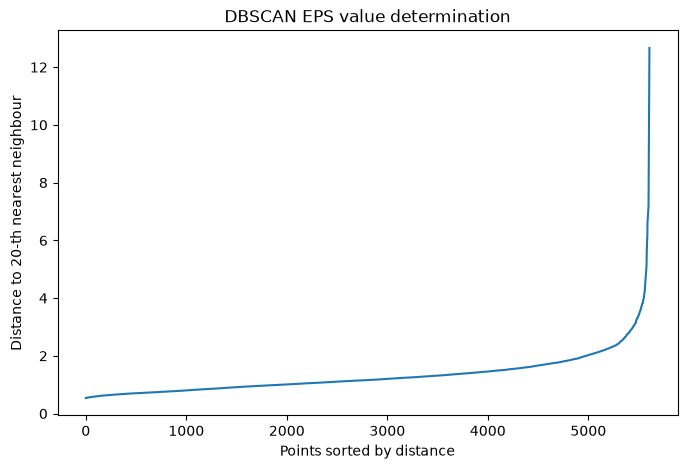

In [236]:
# Initilise variable twice the size og feature_cols
min_samples = 2 * len(feature_cols)

# Initilise variable - 
neighbors = NearestNeighbors(n_neighbors = min_samples)
#
neighbors_fit = neighbors.fit(retail_scaled)
#
distances, indicies = neighbors_fit.kneighbors(retail_scaled)

#
k_distances = np.sort(distances[:, -1])

# Initilise and display Plot: 
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}-th nearest neighbour')
plt.title('DBSCAN EPS value determination')
plt.show()

most points will be close together, hence the flat line, however points that sit further out will start to drag distance out as well, which is where a curve will be formed. The point at which the knee starts represents the distance value that bests suits the data. Here we can see that the curve happens between 2~4. Below a closer inspection will be carried out in order to produce a more concrete answer. 

In [241]:
# Look at the actual distance values around where the bend happens
for position in [4000, 4500, 5000, 5200, 5400,5500, 5600, 5607]:
    print(f"Position {position}: {k_distances[position]:.4f}")

Position 4000: 1.4564
Position 4500: 1.6616
Position 5000: 2.0205
Position 5200: 2.2527
Position 5400: 2.7903
Position 5500: 3.4023
Position 5600: 7.7853
Position 5607: 12.3626


position 5500 shows the first point where values start to climb with an EPS value of 3.4. The code block below will test this value with DBSCAN which should provide some evidence of usable clustering or not. 

In [244]:
# Set the EPS value: 
eps_value = 3.4 
# min_samples has already been initilised. 

# Initilise DBSCAN: 
db = DBSCAN(eps = eps_value, min_samples = min_samples)

# Fit the model with the data: 
db_labels = db.fit_predict(retail_scaled)

# Init variable to count clusters: 
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
# Init variable to count noise: 
n_noise = list(db_labels).count(-1)

# Print results: 
print(f"Clusters Found: {n_clusters}")
print(f"Noise Points: {n_noise}")

Clusters Found: 1
Noise Points: 41


The results here confirm that eps of 3.4 is too high. DBSCAN reutrned one cluster and 41 noise points from 5600 customers, meaning nearly every customer was grouped together into one segement which is not suitable for finding meaningful sub groups. The next test will be to test with a lower eps and examine the results.

In [250]:

# Create a list for eps values recorded between customer 4000 and 5200
eps_values = [1.0, 1.4, 1.6, 2.0, 2.25]

for value in eps_values:
    # re-initilise DBSCAN: 
    db = DBSCAN(eps = value, min_samples = min_samples)
    # Fit the model with the data: 
    db_labels = db.fit_predict(retail_scaled)
    # Init variable to count clusters: 
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    # Init variable to count noise: 
    n_noise = list(db_labels).count(-1)
    # Print results: 
    print(f"eps={value} -> Clusters Found: {n_clusters}, Noise Points: {n_noise}")

eps=1.0 -> Clusters Found: 5, Noise Points: 2599
eps=1.4 -> Clusters Found: 2, Noise Points: 942
eps=1.6 -> Clusters Found: 2, Noise Points: 601
eps=2.0 -> Clusters Found: 2, Noise Points: 267
eps=2.25 -> Clusters Found: 1, Noise Points: 189


Why is DBSCAN finding only 2 segments? its does so naturally unlike KMeans which is asked to do it. shows that DBSCAN is not well suited for this type of ML work. 